In [1]:
from utils import run_model
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
model_parameters = {
    'capacity': 2,      # MWh
    'duration': 4,      # hr
    'dod_min': 0.1,     # 0-1
    'dod_max': 0.9,     # 0-1
    'efficiency': 0.85, # 0-1
    'delta_t': 0.25,    # hr
    'eol': 0.8
}

In [3]:
calendar_parameters = model_parameters.copy()
calendar_parameters.update({
    'lifetime': 10      # years
})

In [4]:
throughput_parameters = model_parameters.copy()
throughput_parameters.update({
    'fade_factor': 2.71e-5    # scalar
})

In [5]:
rainflow_parameters = model_parameters.copy()
rainflow_parameters.update({
    'a': 5.24e-4,    # scalar
    'b': 2.03        # scalar

})


In [6]:
calendar_results = run_model(calendar_parameters, 'calendar')

In [7]:
throughput_results = run_model(throughput_parameters, 'throughput')

In [8]:
rainflow_results = run_model(rainflow_parameters, 'rainflow')

In [9]:
results_dict= {
    "Calendar": calendar_results,
    "Throughput": throughput_results,
    "Rainflow": rainflow_results
}


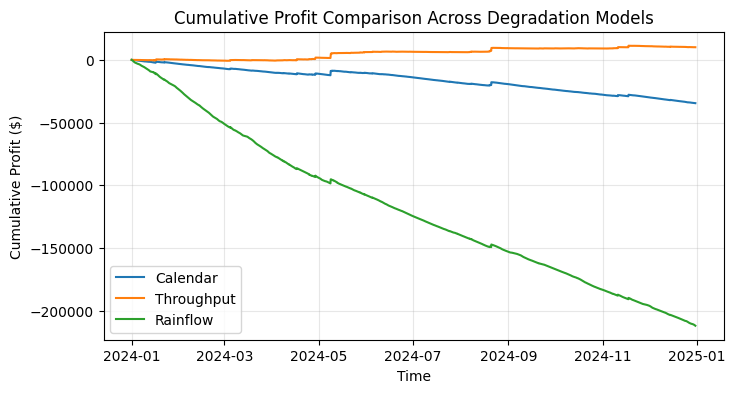

In [10]:
plt.figure(figsize=(8, 4))

for method, df in results_dict.items():
    profit = np.cumsum(df["Grid Transaction ($)"] - df["Degradation Cost ($)"])
    plt.plot(df.index, profit, label=f"{method}")

plt.ylabel("Cumulative Profit ($)")
plt.xlabel("Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Cumulative Profit Comparison Across Degradation Models")

plt.show()


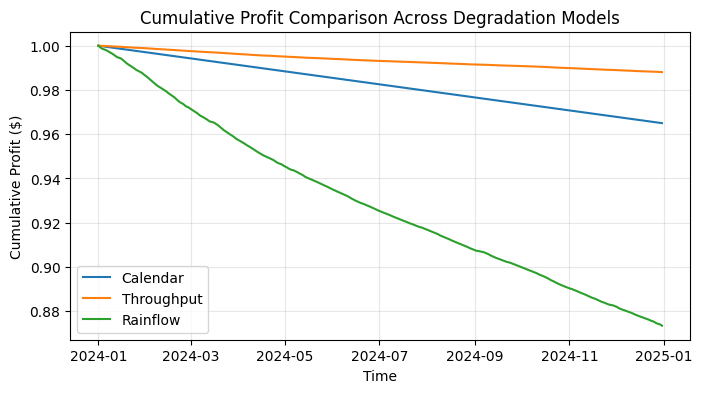

In [11]:
plt.figure(figsize=(8, 4))

for method, df in results_dict.items():
    profit = df["Remaining Capacity (%)"]
    plt.plot(df.index, profit, label=f"{method}")

plt.ylabel("Cumulative Profit ($)")
plt.xlabel("Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Cumulative Profit Comparison Across Degradation Models")

plt.show()
